<a href="https://colab.research.google.com/github/jacobdawson093-tech/Montgomery-County-and-Bias-Incidents-Analysis/blob/main/eda/notebooks/EDA_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingestion

In [4]:
import requests
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import datetime
import os
os.makedirs("graphs", exist_ok=True)

url = "https://api.census.gov/data/2024/acs/acs5"
response = requests.get(url)
data = response.json()
url2 = "https://data.montgomerycountymd.gov/api/v3/views/7bhj-887p/query.json?app_token=8kUbrmGzgoxqe4z7C91iV3wmC"
response2 = requests.get(url2)
data2 = response2.json()

df1 = pd.DataFrame(data)

df2 = pd.DataFrame(data2)
df2.head()

,:id,:version,:created_at,:updated_at,id,incident_date,district,bias_code,bias,status,victim_type,no_of_suspects,suspects_less_than_18_years,unknown,no_of_victims,suspects_36_45_years_old,suspects_55_years_old,bias_code_2,suspects_18_35_years_old,suspects_46_55_years_old
0,row-jqk7~r9v8~gn9q,rv-7acy.s23a-yq4u,2026-05-01T07:11:17.513Z,2026-05-01T07:11:17.513Z,260015370,2026-04-10T00:00:00.000,5D,Anti-Black,Vandalism,Closed-Admin,School/College,1,1,Known,NaN,NaN,NaN,NaN,NaN,NaN
1,row-ac27~z3ht~tkpj,rv-sdjt_wdbv-ffdb,2026-05-01T07:11:17.513Z,2026-05-01T07:11:17.513Z,260015219,2026-04-09T00:00:00.000,3D,Anti-Jewish,Vandalism,Open,School/College,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN
2,row-rnxy~y5m6.vfdz,rv-ywnn~vf3n~jwvz,2026-05-01T07:11:17.513Z,2026-05-01T07:11:17.513Z,260015206,2026-04-09T00:00:00.000,2D,Anti-Jewish,Verbal Intimidation/Simple Assault,Open,Individual(s),1,NaN,Unknown,1,NaN,NaN,NaN,NaN,NaN
3,row-5vip~qvx8-h56u,rv-c22m-iy9x~rpi6,2026-05-01T07:11:17.513Z,2026-05-01T07:11:17.513Z,260015047,2026-04-08T00:00:00.000,4D,Anti-Black,Verbal Intimidation/Simple Assault,Closed-Admin,School/College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,row-kt32_377n~ey23,rv-3inw-3eby-w733,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260013584,2026-03-31T00:00:00.000,6D,Anti-Jewish,Vandalism,Closed-Admin,School/College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Convert 'incident_date' to datetime
df2['incident_date'] = pd.to_datetime(df2['incident_date'])

# Create a binary 'resolved' column from 'status'
df2['resolved'] = df2['status'].apply(lambda x: 1 if x in ['Closed-Admin', 'Closed-Investigation', 'Closed-Exception', 'Closed-Arrest'] else 0)

# Convert suspect age columns to numeric, coercing errors to NaN
df2['suspects_less_than_18_years'] = pd.to_numeric(df2['suspects_less_than_18_years'], errors='coerce').fillna(0).astype(int)
df2['suspects_18_35_years_old'] = pd.to_numeric(df2['suspects_18_35_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_36_45_years_old'] = pd.to_numeric(df2['suspects_36_45_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_46_55_years_old'] = pd.to_numeric(df2['suspects_46_55_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_55_years_old'] = pd.to_numeric(df2['suspects_55_years_old'], errors='coerce').fillna(0).astype(int)

# Create a binary variable for incidents with suspects under 18
df2['under_18_suspect'] = df2['suspects_less_than_18_years'].apply(lambda x: 1 if x > 0 else 0)

#Create bias category to seperate religious bias to racial/ethnic biases
def categorize_bias(bias_code):
    religious_biases = ['Anti-Jewish', 'Anti-Muslim', 'Anti-Catholic', 'Anti-Sikh', 'Anti-Hindhu', 'Anti-Protestant', 'Anti-Buddhist']
    racial_ethnic_biases = ['Anti-Black', 'Anti-White', 'Anti-Asian', 'Anti-Hispanic', 'Anti-Multi-Racial', 'Anti-American Indian', 'Anti-Other Race/Ethnicity']

    if bias_code in religious_biases:
        return 'Religious Bias'
    elif bias_code in racial_ethnic_biases:
        return 'Racial/Ethnic Bias'
    else:
        return 'Other Bias' # For categories not explicitly religious or racial/ethnic

df2['bias_category'] = df2['bias_code'].apply(categorize_bias)

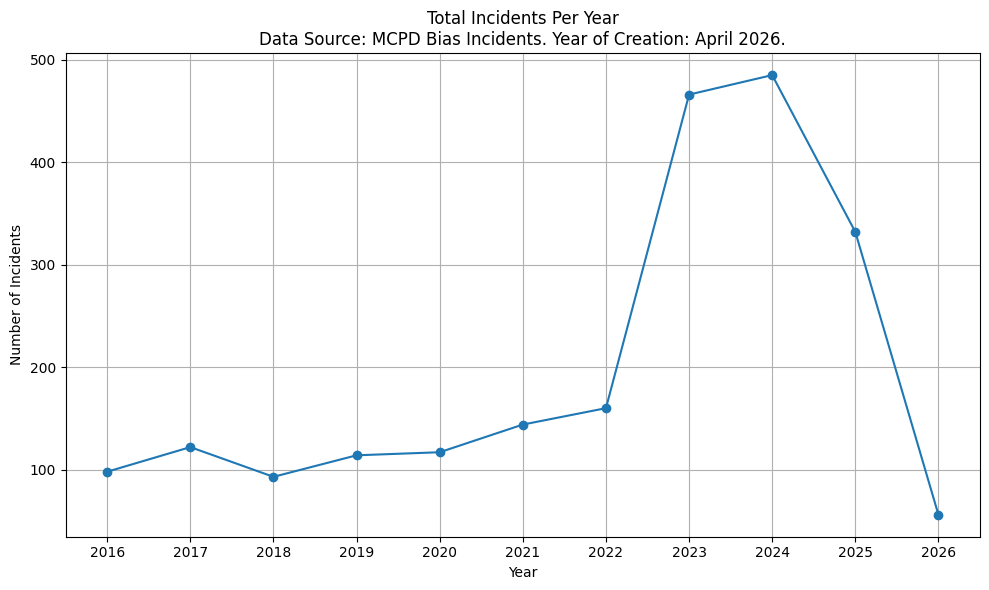

In [6]:
df2['incident_date'] = pd.to_datetime(df2['incident_date'])
incidents_per_year = df2['incident_date'].dt.year.value_counts().sort_index()
incidents_series = pd.Series(incidents_per_year)

incidents_series.index = incidents_series.index.astype(int)

incidents_series = incidents_series.sort_index()

plt.figure(figsize=(10, 6))
plt.plot(incidents_series.index, incidents_series.values, marker='o', linestyle='-')
plt.title('Total Incidents Per Year\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.xticks(incidents_series.index) # Ensure all years are shown on x-axis
plt.tight_layout()
plt.savefig("graphs/Total Incidents Per Year Scatter-Line Plot.png", bbox_inches="tight")
plt.show()

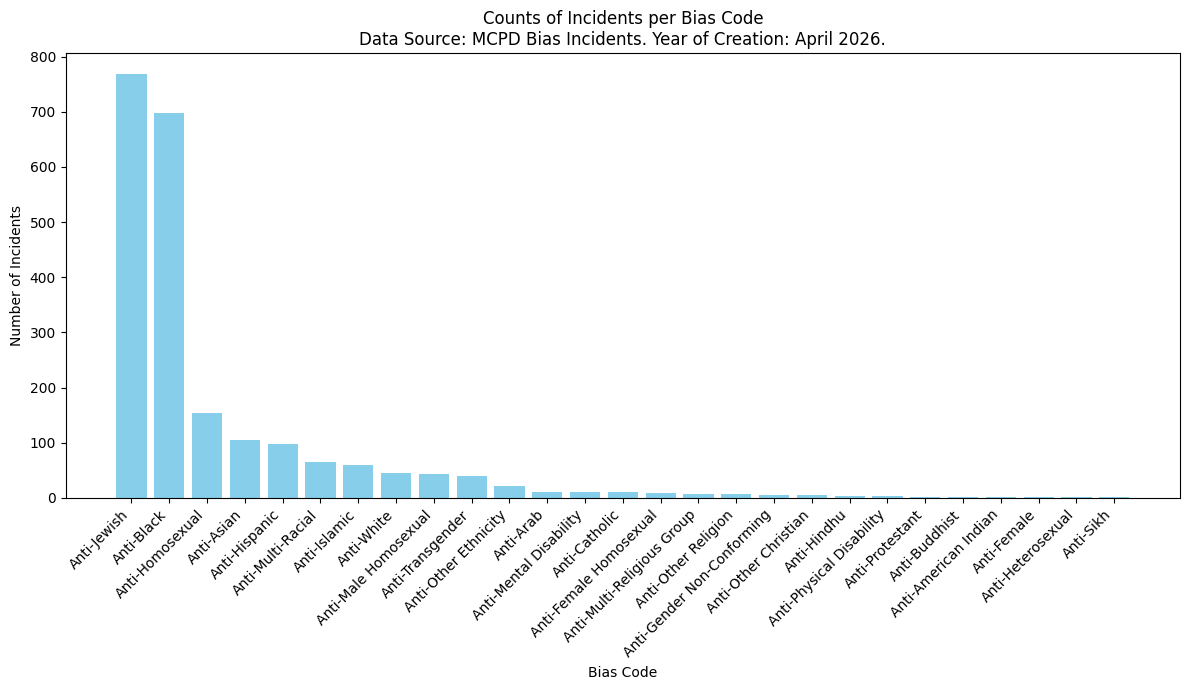

In [7]:

# Initialize a dictionary to store counts of each bias_code
bias_code_counts = {}

# Iterate through the data to count incidents per bias_code
if data2:
    for item in data2:
        if 'bias_code' in item and item['bias_code']:
            bias_code = item['bias_code']
            bias_code_counts[bias_code] = bias_code_counts.get(bias_code, 0) + 1

    # Sort the bias codes by count for better visualization
    sorted_bias_codes = sorted(bias_code_counts.items(), key=lambda x: x[1], reverse=True)
    codes = [item[0] for item in sorted_bias_codes]
    counts = [item[1] for item in sorted_bias_codes]

    # Create the bar plot
    plt.figure(figsize=(12, 7))
    plt.bar(codes, counts, color='skyblue')
    plt.xlabel('Bias Code')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Bias Code\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
    plt.xticks(rotation=45, ha='right') # Rotate labels for readability
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Race - Histogram.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count bias codes.")

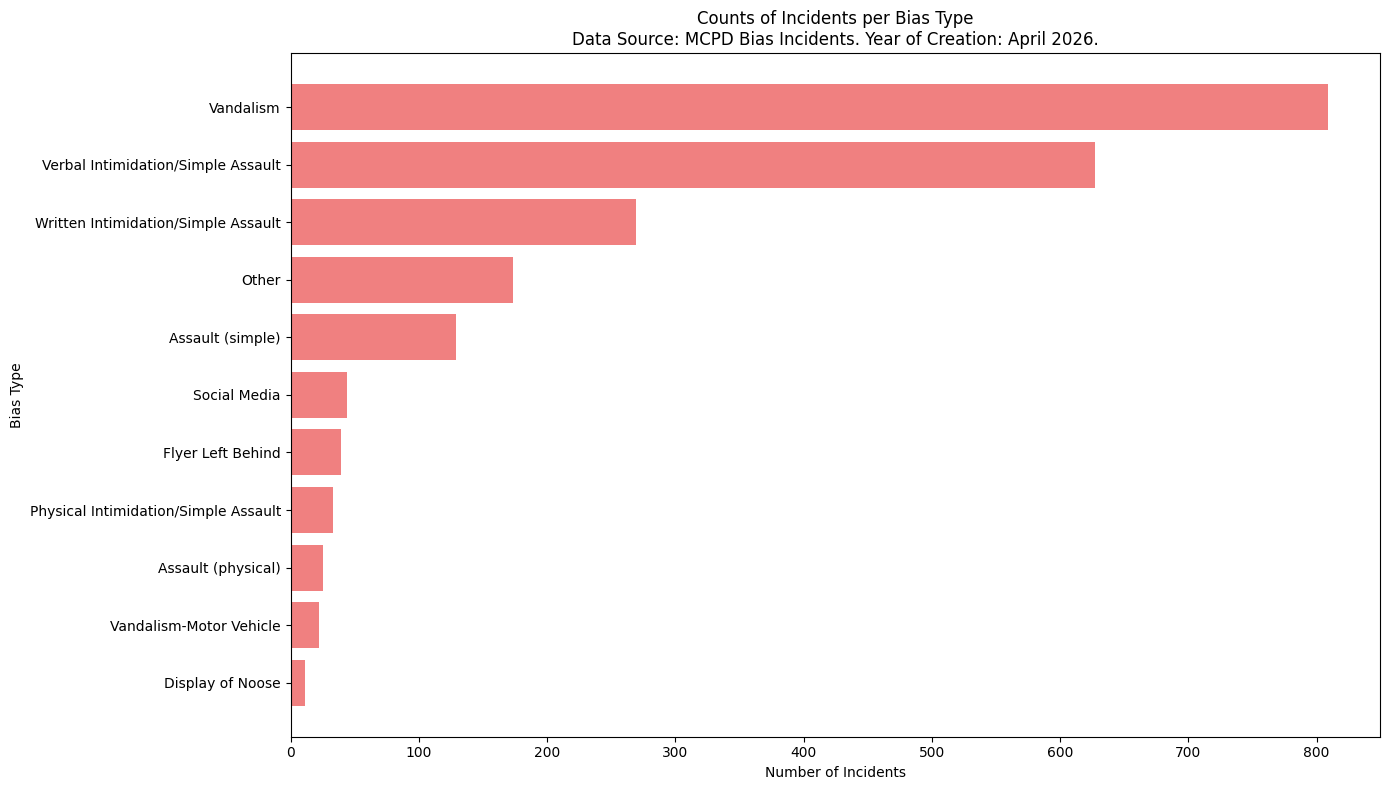

In [8]:
bias_counts = {}

if data2:
    for item in data2:
        if 'bias' in item and item['bias']:
            bias = item['bias']
            bias_counts[bias] = bias_counts.get(bias, 0) + 1

    sorted_bias_counts = sorted(bias_counts.items(), key=lambda x: x[1], reverse=True)
    biases = [item[0] for item in sorted_bias_counts]
    counts = [item[1] for item in sorted_bias_counts]

    plt.figure(figsize=(14, 8))
    # Create horizontal bar chart
    plt.barh(biases[::-1], counts[::-1], color='lightcoral') # Reverse lists to have highest count at top
    plt.ylabel('Bias Type') # Y-axis now shows bias types
    plt.xlabel('Number of Incidents') # X-axis now shows incident counts
    plt.title('Counts of Incidents per Bias Type\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
    os.makedirs("graphs", exist_ok=True)
    plt.yticks(rotation=0) # No rotation needed for y-axis labels
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Bias Type - Horizontal Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count bias types.")

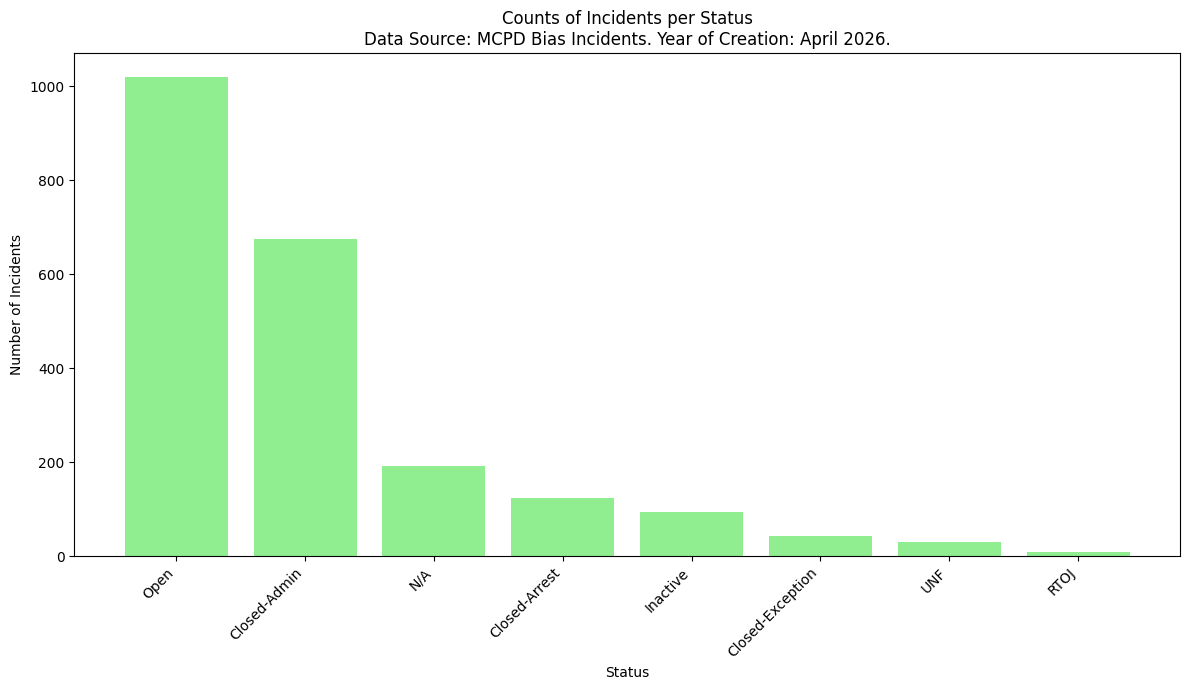

In [9]:
status_counts = {}

if data2:
    for item in data2:
        if 'status' in item and item['status']:
            status = item['status']
            status_counts[status] = status_counts.get(status, 0) + 1

    sorted_status_counts = sorted(status_counts.items(), key=lambda x: x[1], reverse=True)
    statuses = [item[0] for item in sorted_status_counts]
    counts = [item[1] for item in sorted_status_counts]

    plt.figure(figsize=(12, 7))
    plt.bar(statuses, counts, color='lightgreen')
    plt.xlabel('Status')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Status\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
    os.makedirs("graphs", exist_ok=True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Status - Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count statuses.")

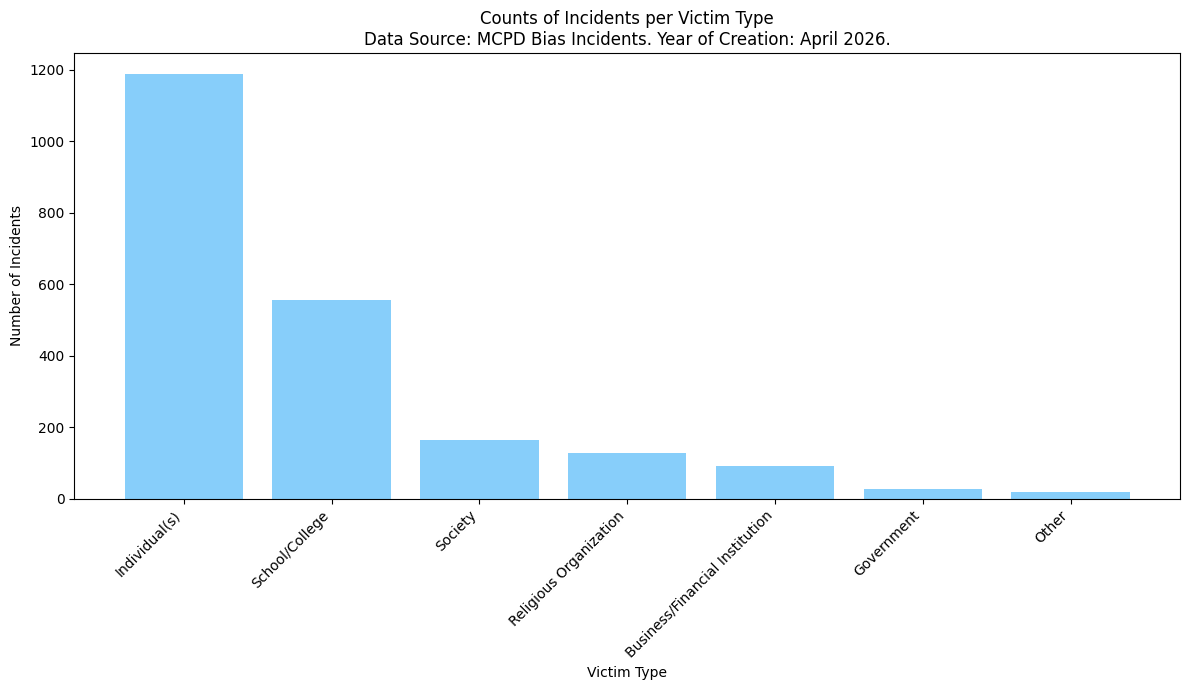

In [10]:
victim_type_counts = {}

if data2:
    for item in data2:
        if 'victim_type' in item and item['victim_type']:
            victim_type = item['victim_type']
            victim_type_counts[victim_type] = victim_type_counts.get(victim_type, 0) + 1

    sorted_victim_type_counts = sorted(victim_type_counts.items(), key=lambda x: x[1], reverse=True)
    victim_types = [item[0] for item in sorted_victim_type_counts]
    counts = [item[1] for item in sorted_victim_type_counts]

    plt.figure(figsize=(12, 7))
    plt.bar(victim_types, counts, color='lightskyblue')
    plt.xlabel('Victim Type')
    plt.ylabel('Number of Incidents')
    plt.title('Counts of Incidents per Victim Type\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
    os.makedirs("graphs", exist_ok=True)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("graphs/Counts of Incidents per Victim Type - Bar Chart.png", bbox_inches="tight")
    plt.show()
else:
    print("No data found in the response to count victim types.")

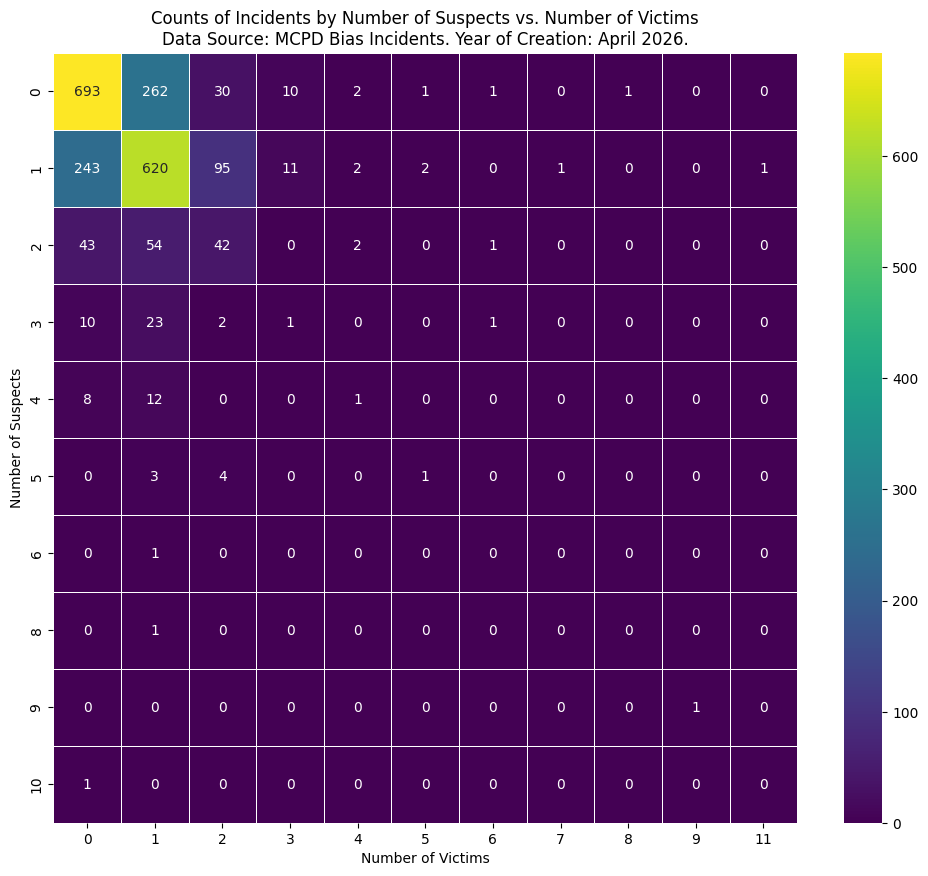

In [11]:

# Create a DataFrame from the incident data
# Assuming data2 is already loaded and contains the incident information
incident_df = pd.DataFrame(data2)

# Convert 'no_of_suspects' and 'no_of_victims' to numeric
# Coerce errors to NaN, then fill NaN with 0 as requested for 'empty' values in a count context
incident_df['no_of_suspects'] = pd.to_numeric(incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)
incident_df['no_of_victims'] = pd.to_numeric(incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Calculate the counts of incidents for each combination of suspects and victims
counts_matrix = incident_df.groupby(['no_of_suspects', 'no_of_victims']).size().unstack(fill_value=0)

# Ensure all possible suspect/victim counts are covered in the index/columns if needed for consistency
# For example, if max suspects is 5 but 3 is missing, unstack might not create it. fill_value=0 handles this for the existing range.

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(counts_matrix, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Counts of Incidents by Number of Suspects vs. Number of Victims\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Number of Victims')
plt.ylabel('Number of Suspects')
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Suspects vs Victims Heatmap.png", bbox_inches="tight")
plt.show()

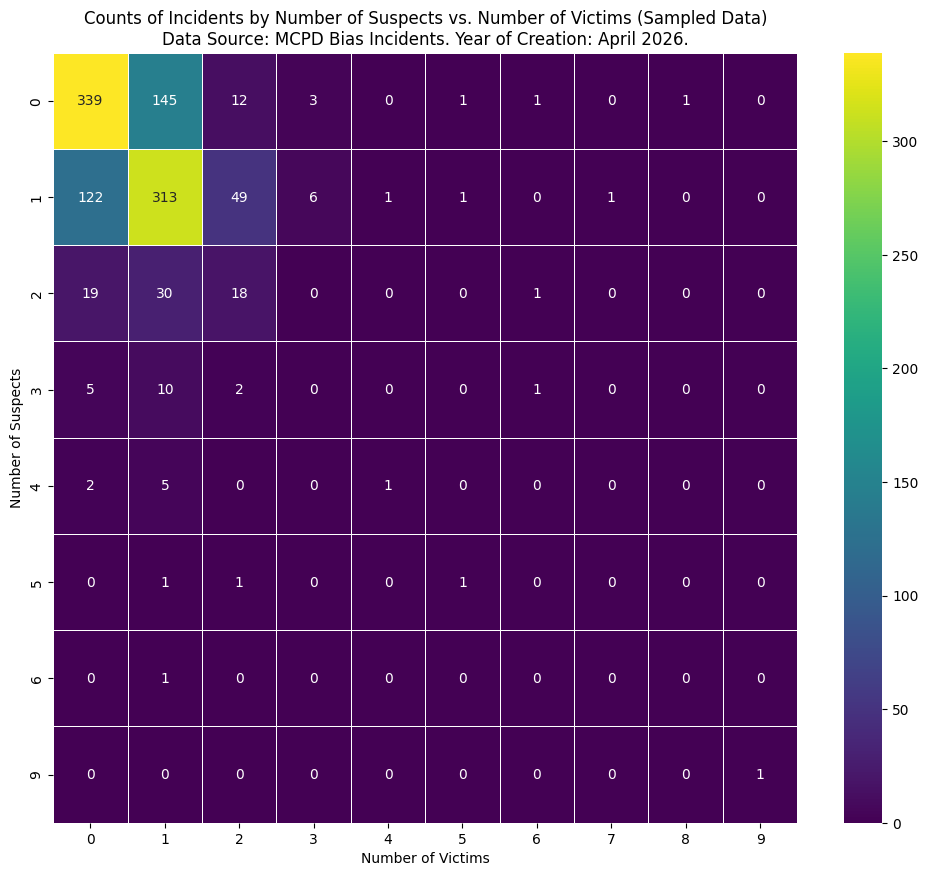

In [12]:

# Take a sample of the incident_df
# Using a fraction of 0.5 (50% of the data) for the sample
sampled_incident_df = incident_df.sample(frac=0.5, random_state=42) # random_state for reproducibility

# Convert 'no_of_suspects' and 'no_of_victims' to numeric
sampled_incident_df['no_of_suspects'] = pd.to_numeric(sampled_incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)
sampled_incident_df['no_of_victims'] = pd.to_numeric(sampled_incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Calculate the counts of incidents for each combination of suspects and victims in the sample
sampled_counts_matrix = sampled_incident_df.groupby(['no_of_suspects', 'no_of_victims']).size().unstack(fill_value=0)

# Create the heatmap for the sampled data
plt.figure(figsize=(12, 10))
sns.heatmap(sampled_counts_matrix, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Counts of Incidents by Number of Suspects vs. Number of Victims (Sampled Data)\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Number of Victims')
plt.ylabel('Number of Suspects')
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Suspects vs Victims Heatmap_Sampled.png", bbox_inches="tight")
plt.show()

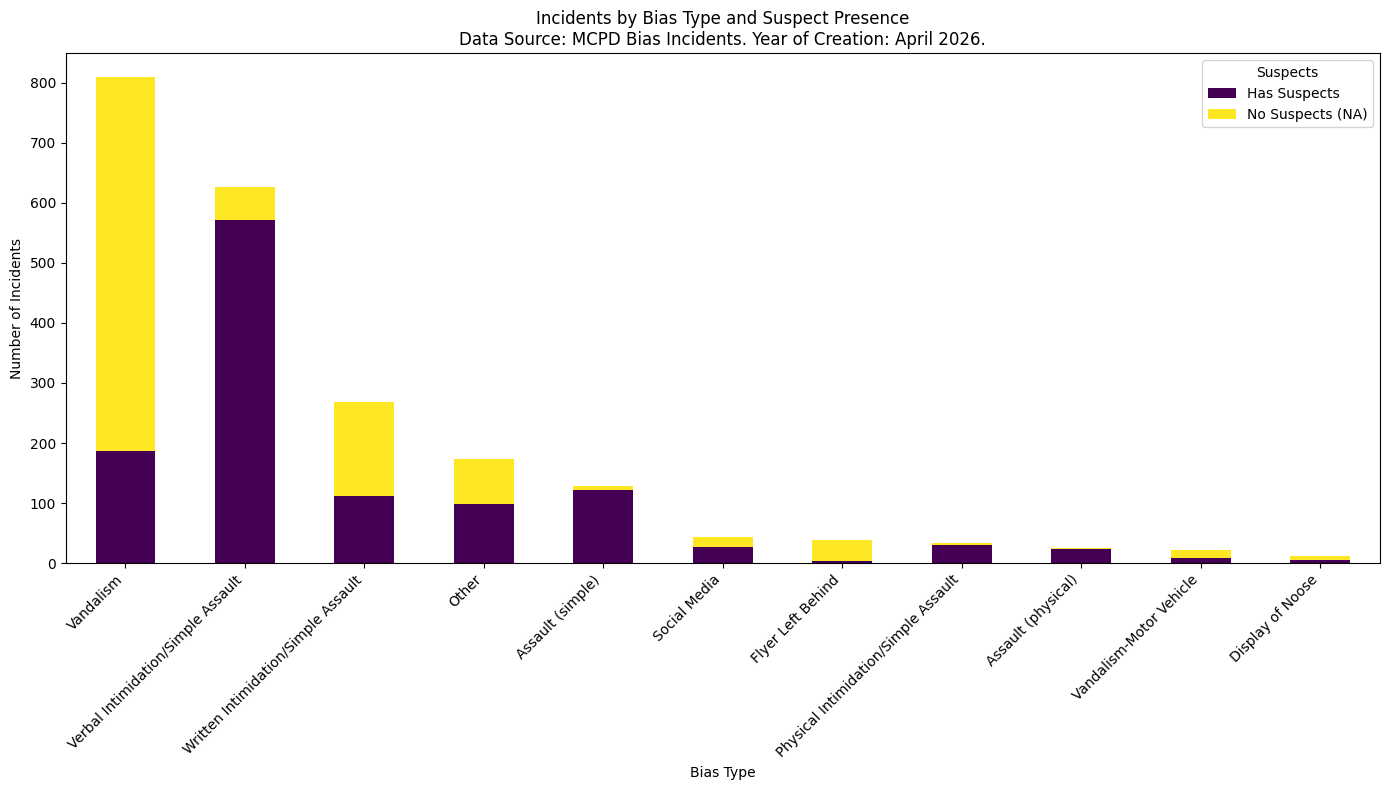

In [13]:

# Ensure incident_df is available from previous steps
# If not, recreate it:
# incident_df = pd.DataFrame(data2)
# incident_df['no_of_suspects'] = pd.to_numeric(incident_df['no_of_suspects'], errors='coerce').fillna(0).astype(int)

# Create a new column to categorize incidents based on 'no_of_suspects'
incident_df['suspect_presence'] = incident_df['no_of_suspects'].apply(lambda x: 'No Suspects (NA)' if x == 0 else 'Has Suspects')

# Group by 'bias' and 'suspect_presence' to get counts
bias_suspect_counts = incident_df.groupby(['bias', 'suspect_presence']).size().unstack(fill_value=0)

# Sort biases by total incident count for better visualization
bias_order = bias_suspect_counts.sum(axis=1).sort_values(ascending=False).index
bias_suspect_counts = bias_suspect_counts.loc[bias_order]

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))
bias_suspect_counts.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())

plt.title('Incidents by Bias Type and Suspect Presence\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Suspects')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Type and Suspect Presence - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()

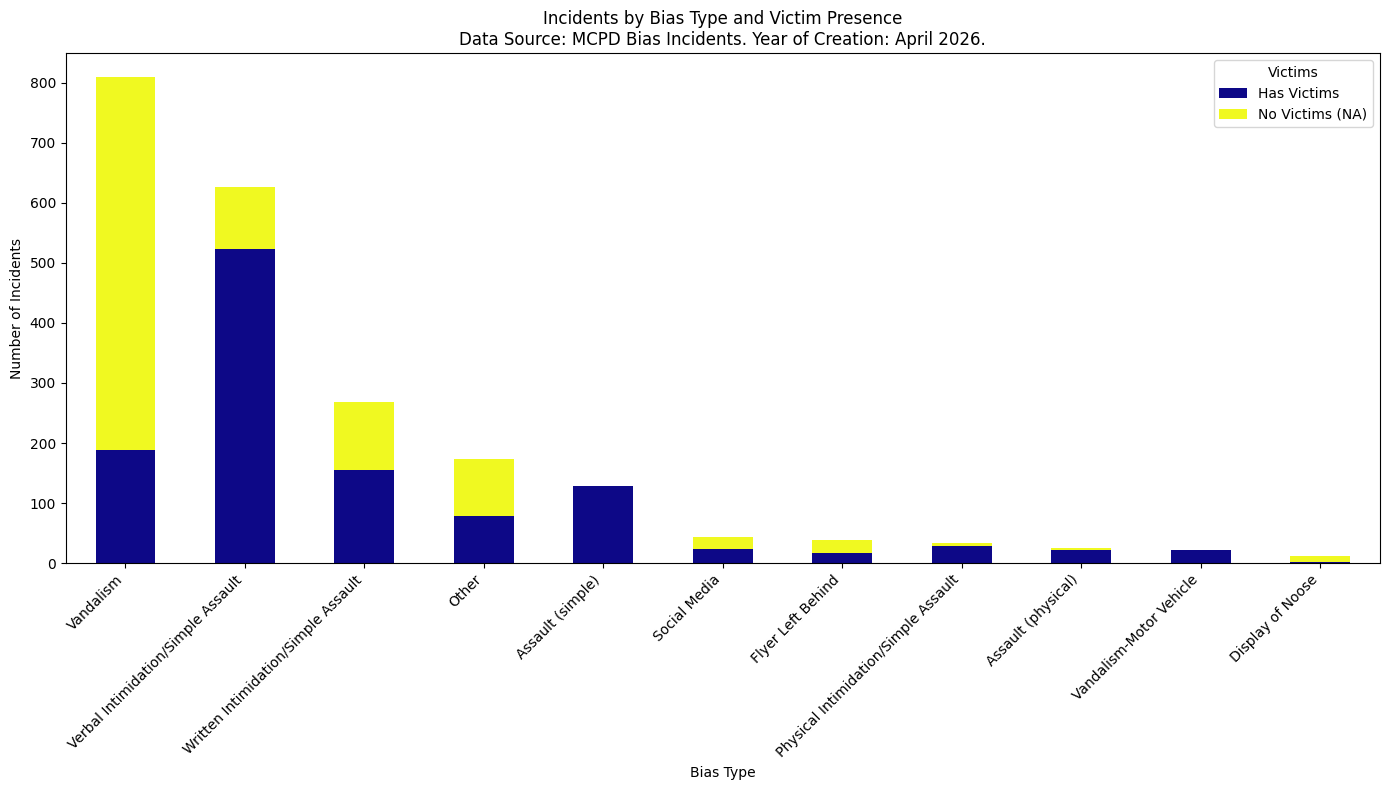

In [14]:

# Ensure incident_df is available from previous steps
# If not, recreate it:
# incident_df = pd.DataFrame(data2)
# incident_df['no_of_victims'] = pd.to_numeric(incident_df['no_of_victims'], errors='coerce').fillna(0).astype(int)

# Create a new column to categorize incidents based on 'no_of_victims'
incident_df['victim_presence'] = incident_df['no_of_victims'].apply(lambda x: 'No Victims (NA)' if x == 0 else 'Has Victims')

# Group by 'bias' and 'victim_presence' to get counts
bias_victim_presence_counts = incident_df.groupby(['bias', 'victim_presence']).size().unstack(fill_value=0)

# Sort biases by total incident count for better visualization
bias_order = bias_victim_presence_counts.sum(axis=1).sort_values(ascending=False).index
bias_victim_presence_counts = bias_victim_presence_counts.loc[bias_order]

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))
bias_victim_presence_counts.plot(kind='bar', stacked=True, cmap='plasma', ax=plt.gca())

plt.title('Incidents by Bias Type and Victim Presence\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Victims')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Type and Victim Presence - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()


### Incidents per Police District

Let's visualize the number of incidents reported in each police district to understand the geographical distribution of bias incidents.

/tmp/ipykernel_18654/453475455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_counts.index, y=district_counts.values, palette='viridis')


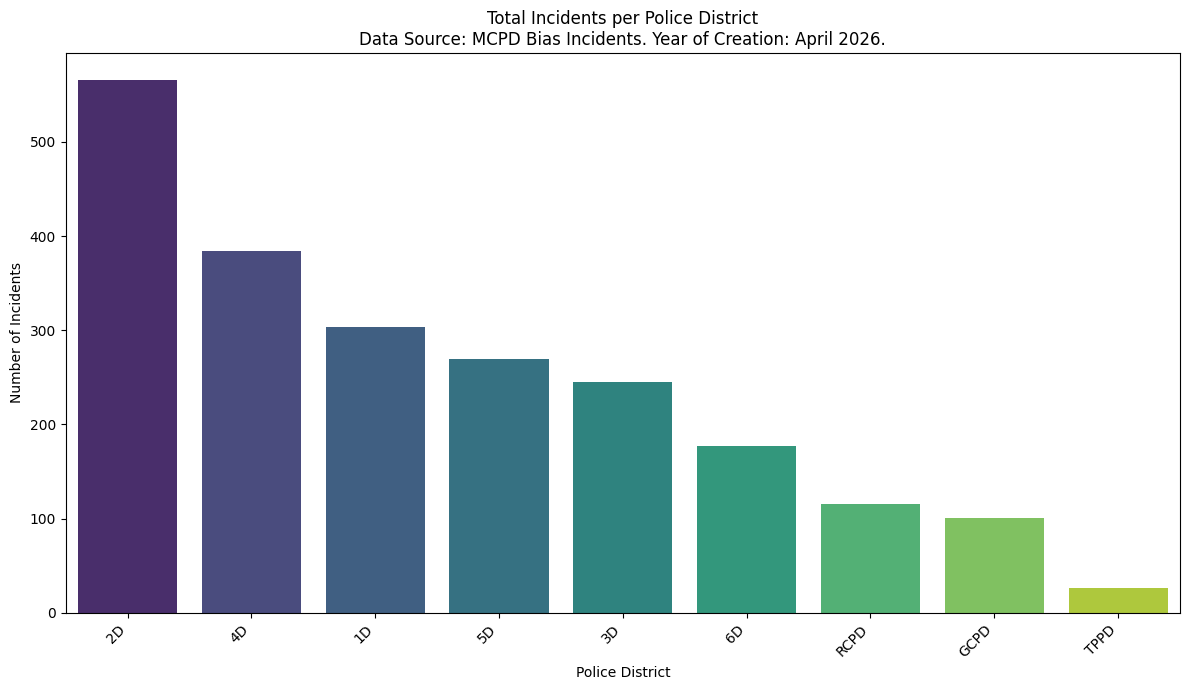

In [15]:
district_counts = incident_df['district'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=district_counts.index, y=district_counts.values, palette='viridis')
plt.title('Total Incidents per Police District\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Police District')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Incidents per Police District - Bar Chart.png", bbox_inches="tight")
plt.show()

### Bias Types by Police District

Now, let's explore which bias types are most prevalent in each police district using a stacked bar chart.

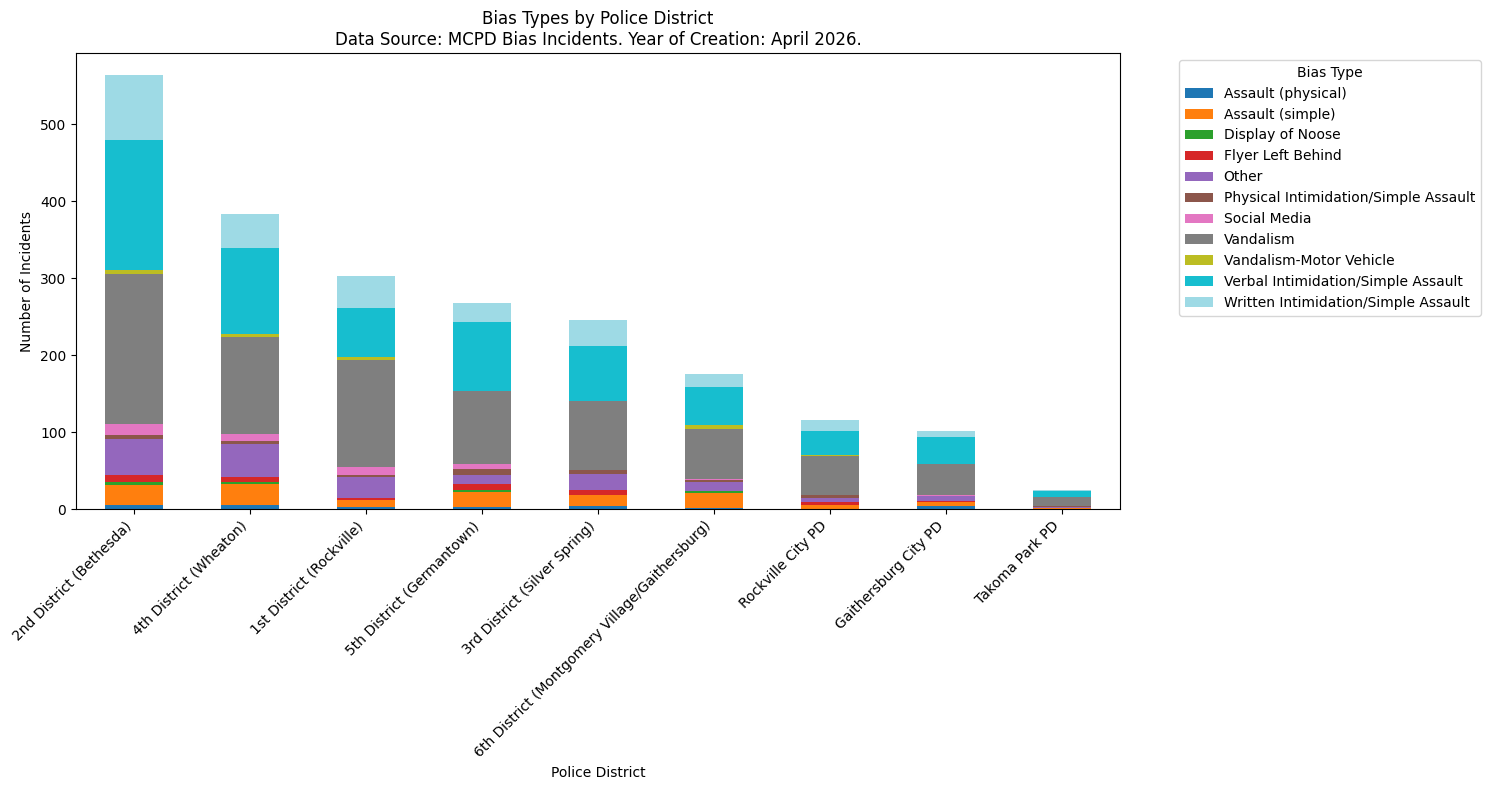

In [16]:
district_bias_counts = incident_df.groupby(['district', 'bias']).size().unstack(fill_value=0)

# Sort districts by total incidents for better visualization
district_order = district_bias_counts.sum(axis=1).sort_values(ascending=False).index
district_bias_counts = district_bias_counts.loc[district_order]

# Define a mapping from district codes to full names
district_name_mapping = {
    '1D': '1st District (Rockville)',
    '2D': '2nd District (Bethesda)',
    '3D': '3rd District (Silver Spring)',
    '4D': '4th District (Wheaton)',
    '5D': '5th District (Germantown)',
    '6D': '6th District (Montgomery Village/Gaithersburg)',
    'RCPD': 'Rockville City PD',
    'GCPD': 'Gaithersburg City PD',
    'TPPD': 'Takoma Park PD'
}

# Apply the mapping to the district order to get new labels
new_x_labels = [district_name_mapping.get(d, d) for d in district_order]

plt.figure(figsize=(15, 8))
district_bias_counts.plot(kind='bar', stacked=True, cmap='tab20', ax=plt.gca())
plt.title('Bias Types by Police District\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Police District')
plt.ylabel('Number of Incidents')
plt.xticks(ticks=range(len(new_x_labels)), rotation=45, ha='right', labels=new_x_labels)
plt.legend(title='Bias Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Bias Types by Police District - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()

### Victim Type vs. Bias Type

This visualization will show the relationship between the type of bias and the type of victim involved in the incidents.

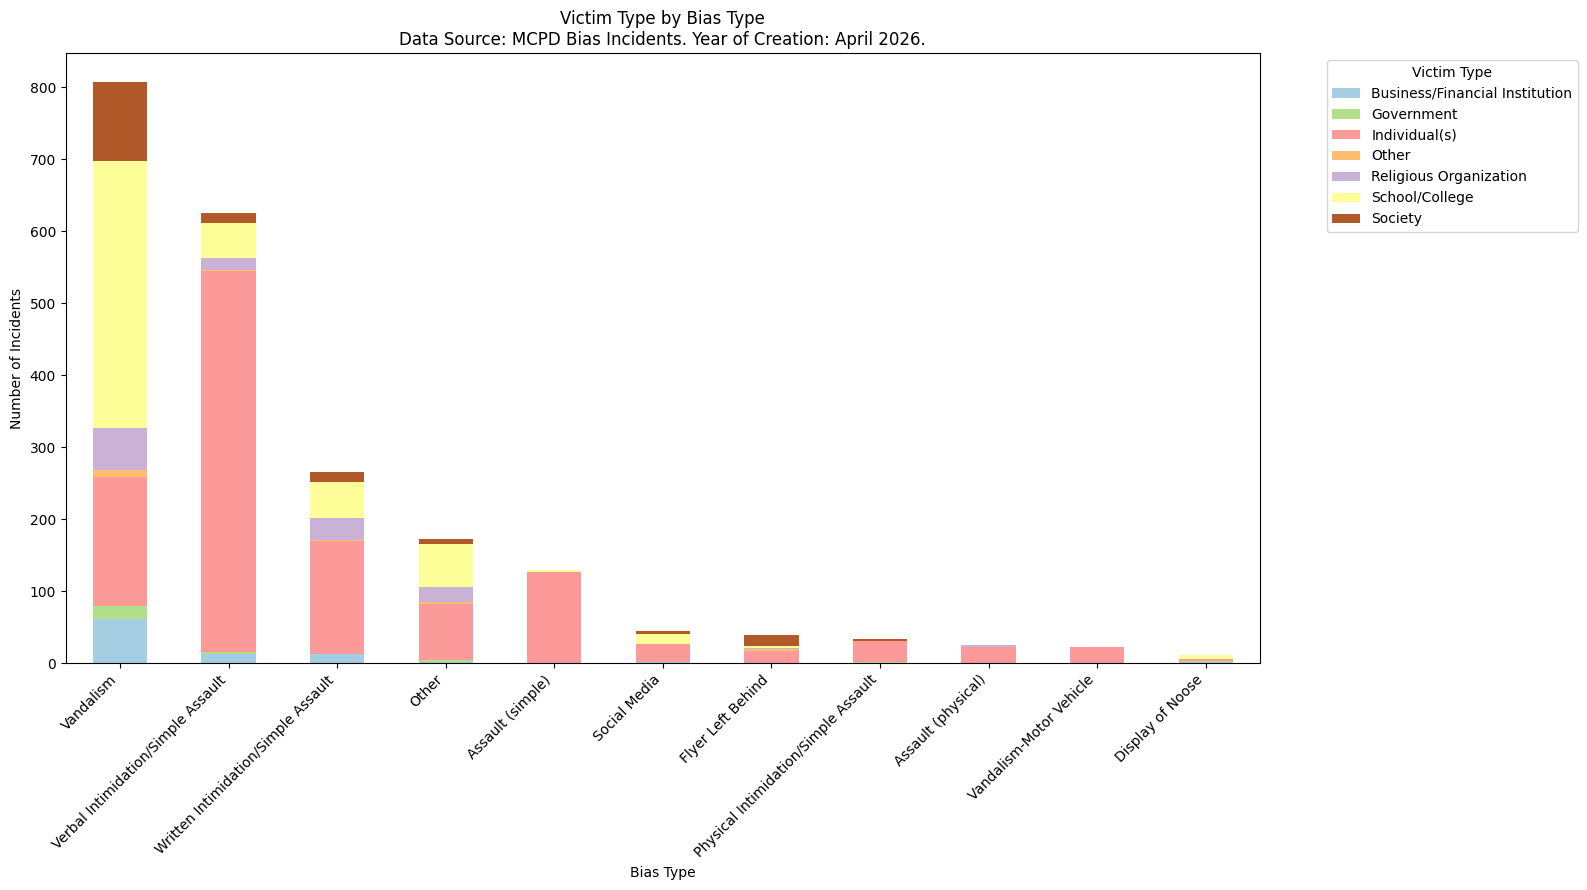

In [17]:
bias_victim_type_counts = incident_df.groupby(['bias', 'victim_type']).size().unstack(fill_value=0)

# Sort biases by total incident count
bias_order_victim_type = bias_victim_type_counts.sum(axis=1).sort_values(ascending=False).index
bias_victim_type_counts = bias_victim_type_counts.loc[bias_order_victim_type]

plt.figure(figsize=(16, 9))
bias_victim_type_counts.plot(kind='bar', stacked=True, cmap='Paired', ax=plt.gca())
plt.title('Victim Type by Bias Type\nData Source: MCPD Bias Incidents. Year of Creation: April 2026.')
plt.xlabel('Bias Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Victim Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
os.makedirs("graphs", exist_ok=True)
plt.savefig("graphs/Victim Type by Bias Type - Stacked Bar Chart.png", bbox_inches="tight")
plt.show()